SALES FORECASTING ANALYSIS
============================================================================

Company: GlobalMart Retail
Project: Monthly Sales Forecasting for 2026

PURPOSE:
Analyze historical sales data (2023-2025) and forecast future sales for 2026
to help with inventory planning, staffing, and budget allocation.

BUSINESS QUESTION:

What will our monthly sales be in 2026 so we can plan accordingly?

WHAT THIS DOES:
1. Load historical sales data
2. Analyze trends and patterns
3. Build simple forecasting model using trend + seasonality
4. Predict sales for next 12 months
5. Provide business recommendations

METHOD:
We use a simple but effective forecasting method:
- Trend: Linear growth based on historical data
- Seasonality: Average patterns by month
- Forecast = Trend × Seasonality

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

1. LOAD HISTORICAL DATA


In [ ]:

# Load the CSV file
df = pd.read_csv('globalmart_sales_data.csv')

# Inspect data
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        36 non-null     object 
 1   sales       36 non-null     float64
 2   year        36 non-null     int64  
 3   month       36 non-null     int64  
 4   month_name  36 non-null     object 
 5   quarter     36 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ KB


In [ ]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

2. EXPLORATORY ANALYSIS

In [ ]:
# Calculate yearly sales
yearly_sales = df.groupby('year')['sales'].sum()

# Calculate year-over-year growth
yearly_growth = (yearly_sales.pct_change() * 100).round(1)

In [ ]:
# Combine results into a summary table
yearly_summary = pd.DataFrame({
    'Total Sales ($)': yearly_sales,
    'YoY Growth (%)': yearly_growth
})

yearly_summary

,Total Sales ($),YoY Growth (%)
year,,
2023,30859859.20,NaN
2024,40685781.14,31.8
2025,60123395.83,47.8


In [ ]:
# Identify best and worst sales month
best_month = df.loc[df['sales'].idxmax()]
worst_month = df.loc[df['sales'].idxmin()]

summary = pd.DataFrame({
    "Performance": ["Best Month", "Worst Month"],
    "Year": [best_month['year'], worst_month['year']],
    "Month": [best_month['month_name'], worst_month['month_name']],
    "Sales ($)": [best_month['sales'], worst_month['sales']]
})

summary

,Performance,Year,Month,Sales ($)
0,Best Month,2025,November,7982865.29
1,Worst Month,2023,February,1929941.68


3. TREND AND SEASONALITY ANALYSIS

1.  Is sales generally growing over time? - Trend

2. Do some months always perform better than others? - Seasonality

To understand long-term business growth and recurring monthly patterns, sales were decomposed into a trend component (overall growth) and seasonal indices (monthly performance relative to the trend).

In [ ]:
# Create time index for trend calculation
df['month_index'] = range(len(df))

# Fit linear trend line (y = mx + b)
slope, intercept = np.polyfit(df['month_index'], df['sales'], 1)

print("\nTrend Analysis:")
print(f"Monthly growth rate: ${slope:,.0f} per month")
print(f"Starting baseline: ${intercept:,.0f}")


Trend Analysis:
Monthly growth rate: $113,972 per month
Starting baseline: $1,662,961


In [ ]:
# Calculate trend values
df['trend'] = slope * df['month_index'] + intercept

# Calculate seasonal factors
df['seasonal_factor'] = df['sales'] / df['trend']

# Average seasonal pattern for each month
seasonal_indices = df.groupby('month')['seasonal_factor'].mean()

print("\nSeasonal Indices (1.0 = average month):")

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, name in enumerate(month_names, start=1):
    print(f"{name}: {seasonal_indices[i]:.2f}x")


Seasonal Indices (1.0 = average month):
Jan: 1.09x
Feb: 0.90x
Mar: 0.93x
Apr: 1.03x
May: 0.90x
Jun: 0.91x
Jul: 0.87x
Aug: 0.92x
Sep: 1.03x
Oct: 1.02x
Nov: 1.31x
Dec: 1.20x


4. FORECASTING 2026 SALES

In [ ]:
# Forecast for 12 months
months_2026 = range(1, 13)
forecast_df = pd.DataFrame({
    'date': [pd.Timestamp(2026, m, 1) for m in months_2026],
    'month': months_2026,
    'month_name': [pd.Timestamp(2026, m, 1).strftime('%B') for m in months_2026],
})

In [ ]:
# Calculate month index (continuing from historical data)
forecast_df['month_index'] = 35 + forecast_df['month']  # Jan 2026 = 36

In [ ]:
# Apply trend
forecast_df['trend'] = slope * forecast_df['month_index'] + intercept

In [ ]:
# Apply seasonal factors
forecast_df['forecasted_sales'] = forecast_df.apply(
    lambda row: row['trend'] * seasonal_indices[row['month']], axis=1
)

In [ ]:
# Confidence intervals ±10%
forecast_df['lower_bound'] = forecast_df['forecasted_sales'] * 0.9
forecast_df['upper_bound'] = forecast_df['forecasted_sales'] * 1.1

# Keep only relevant columns
forecast_df = forecast_df[['date','month','month_name','forecasted_sales','lower_bound','upper_bound']]

print("\n✓ Generated forecasts for 12 months (Jan-Dec 2026)")
forecast_df


✓ Generated forecasts for 12 months (Jan-Dec 2026)


,date,month,month_name,forecasted_sales,lower_bound,upper_bound
0,2026-01-01,1,January,6.256298e+06,5.630668e+06,6.881927e+06
1,2026-02-01,2,February,5.282258e+06,4.754032e+06,5.810483e+06
2,2026-03-01,3,March,5.570421e+06,5.013379e+06,6.127463e+06
3,2026-04-01,4,April,6.312434e+06,5.681190e+06,6.943677e+06
4,2026-05-01,5,May,5.590983e+06,5.031885e+06,6.150082e+06
5,2026-06-01,6,June,5.782387e+06,5.204148e+06,6.360625e+06
6,2026-07-01,7,July,5.629625e+06,5.066662e+06,6.192587e+06
7,2026-08-01,8,August,6.045713e+06,5.441142e+06,6.650285e+06
8,2026-09-01,9,September,6.910932e+06,6.219839e+06,7.602025e+06
9,2026-10-01,10,October,6.958564e+06,6.262707e+06,7.654420e+06


5. ANALYZE FORECAST RESULTS


In [ ]:
# Display forecast table (month, forecast, lower/upper bounds)
forecast_display = forecast_df.copy()
forecast_display['forecasted_sales'] = forecast_display['forecasted_sales'].map('${:,.0f}'.format)
forecast_display['lower_bound'] = forecast_display['lower_bound'].map('${:,.0f}'.format)
forecast_display['upper_bound'] = forecast_display['upper_bound'].map('${:,.0f}'.format)

forecast_display[['month_name','forecasted_sales','lower_bound','upper_bound']]

,month_name,forecasted_sales,lower_bound,upper_bound
0,January,"$6,256,298","$5,630,668","$6,881,927"
1,February,"$5,282,258","$4,754,032","$5,810,483"
2,March,"$5,570,421","$5,013,379","$6,127,463"
3,April,"$6,312,434","$5,681,190","$6,943,677"
4,May,"$5,590,983","$5,031,885","$6,150,082"
5,June,"$5,782,387","$5,204,148","$6,360,625"
6,July,"$5,629,625","$5,066,662","$6,192,587"
7,August,"$6,045,713","$5,441,142","$6,650,285"
8,September,"$6,910,932","$6,219,839","$7,602,025"
9,October,"$6,958,564","$6,262,707","$7,654,420"


In [ ]:
# Summary metrics
total_forecast_2026 = forecast_df['forecasted_sales'].sum()
avg_monthly_2026 = forecast_df['forecasted_sales'].mean()
total_2025 = df[df['year']==2025]['sales'].sum()
growth_vs_2025 = ((total_forecast_2026 - total_2025)/total_2025)*100

summary = pd.DataFrame({
    'Metric': ['2025 Actual Revenue','2026 Forecast Revenue','Expected Growth vs 2025'],
    'Value': [f"${total_2025:,.0f}", f"${total_forecast_2026:,.0f}", f"+{growth_vs_2025:.1f}%"]
})
summary

,Metric,Value
0,2025 Actual Revenue,"$60,123,396"
1,2026 Forecast Revenue,"$77,790,898"
2,Expected Growth vs 2025,+29.4%


In [ ]:
# Identify peak and low months
peak_month = forecast_df.loc[forecast_df['forecasted_sales'].idxmax()]
low_month = forecast_df.loc[forecast_df['forecasted_sales'].idxmin()]

peak_low = pd.DataFrame({
    'Type': ['Peak Month','Low Month'],
    'Month': [peak_month['month_name'], low_month['month_name']],
    'Forecasted Sales': [f"${peak_month['forecasted_sales']:,.0f}", f"${low_month['forecasted_sales']:,.0f}"]
})
peak_low

,Type,Month,Forecasted Sales
0,Peak Month,November,"$9,035,079"
1,Low Month,February,"$5,282,258"


In [ ]:
# Identify peak and low months in 2026
peak_month_2026 = forecast_df.loc[forecast_df['forecasted_sales'].idxmax()]
low_month_2026 = forecast_df.loc[forecast_df['forecasted_sales'].idxmin()]

6: CREATE VISUALIZATIONS

In [ ]:
# Helper function to format y-axis in millions
def millions(x, pos):
    return f"${x/1e6:.1f}M"

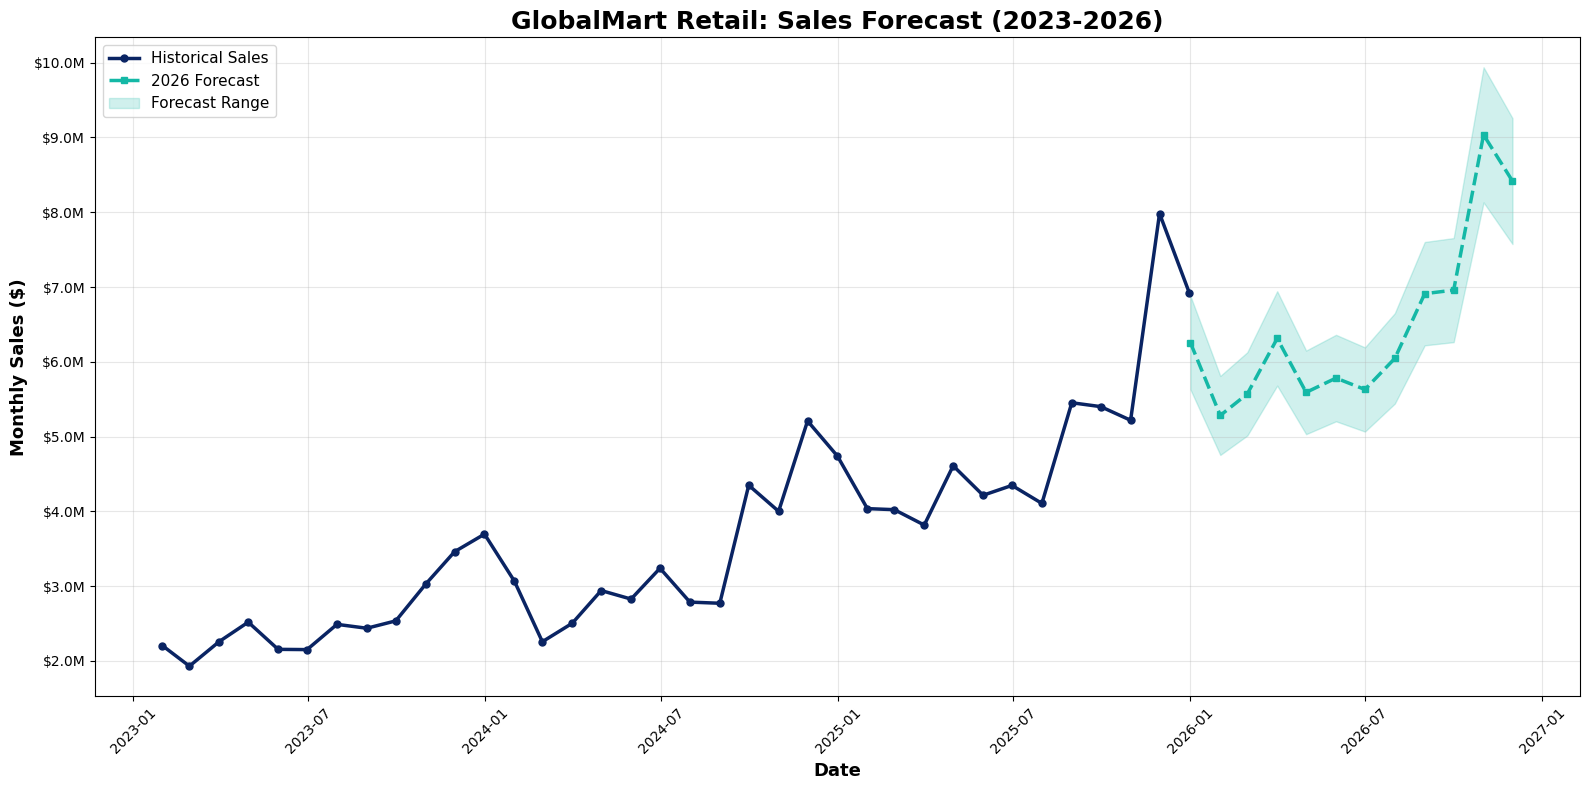

In [ ]:
# Chart 1: Historical + Forecast
plt.figure(figsize=(16, 8))
plt.plot(df['date'], df['sales'], marker='o', linewidth=2.5, markersize=5, color='#0A2463', label='Historical Sales')
plt.plot(forecast_df['date'], forecast_df['forecasted_sales'], marker='s', linewidth=2.5, markersize=5, color='#14B8A6', linestyle='--', label='2026 Forecast')
plt.fill_between(forecast_df['date'], forecast_df['lower_bound'], forecast_df['upper_bound'], color='#14B8A6', alpha=0.2, label='Forecast Range')

plt.title('GlobalMart Retail: Sales Forecast (2023-2026)', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=13, fontweight='bold')
plt.ylabel('Monthly Sales ($)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_sales_forecast.png', dpi=300, bbox_inches='tight');

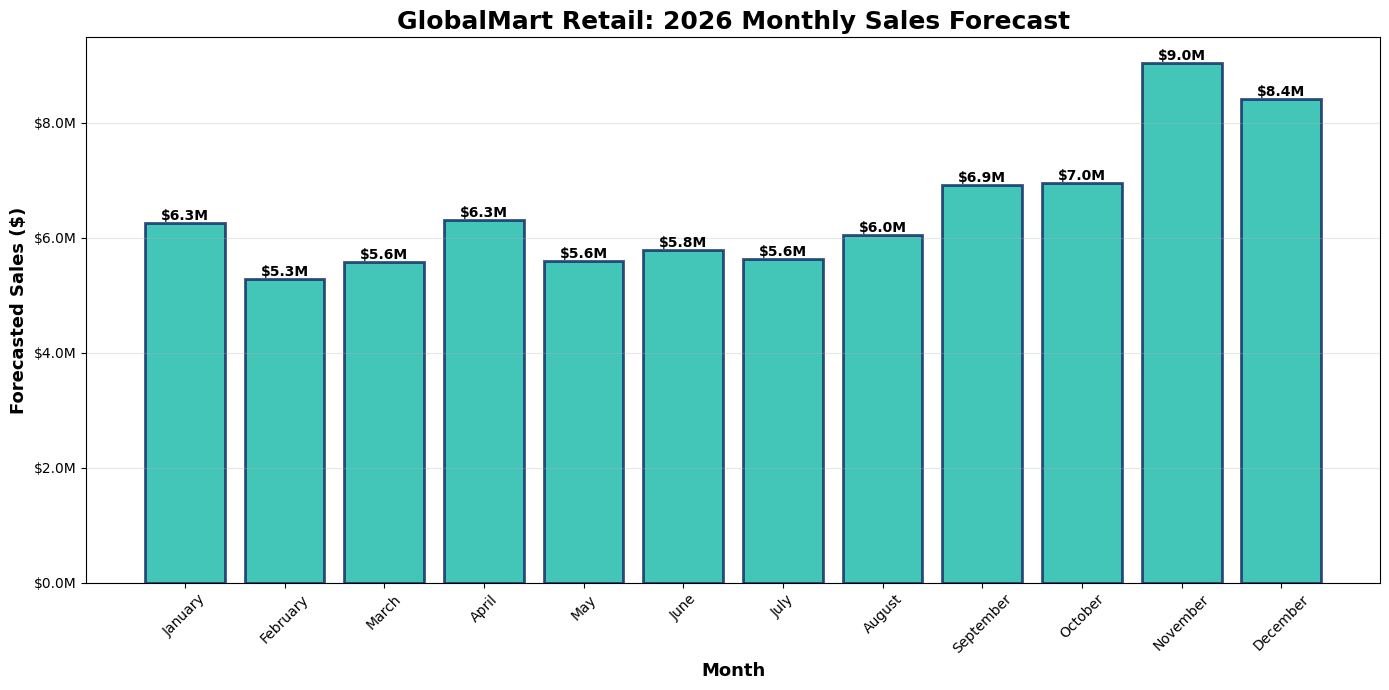

In [ ]:
# Chart 2: 2026 Monthly Breakdown
plt.figure(figsize=(14, 7))
bars = plt.bar(forecast_df['month_name'], forecast_df['forecasted_sales'], color='#14B8A6', edgecolor='#0A2463', linewidth=2, alpha=0.8)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"${bar.get_height()/1e6:.1f}M", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('GlobalMart Retail: 2026 Monthly Sales Forecast', fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=13, fontweight='bold')
plt.ylabel('Forecasted Sales ($)', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_2026_monthly.png', dpi=300, bbox_inches='tight');

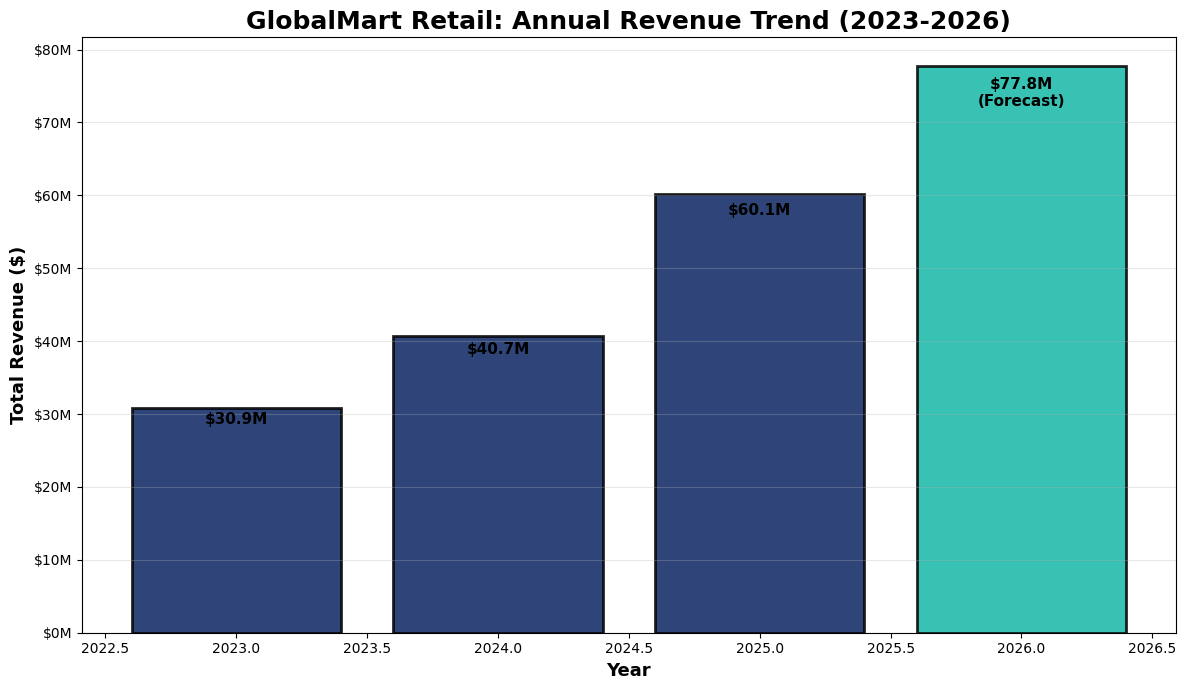

In [ ]:
# Years and revenues
years = [2023, 2024, 2025, 2026]
revenues = [
    df[df['year']==2023]['sales'].sum(),
    df[df['year']==2024]['sales'].sum(),
    df[df['year']==2025]['sales'].sum(),
    total_forecast_2026
]

# Highlight forecast year
colors = ['#0A2463']*3 + ['#14B8A6']

plt.figure(figsize=(12,7))
bars = plt.bar(years, revenues, color=colors, edgecolor='black', linewidth=2, alpha=0.85)

# Add labels at the top inside bars
for year, rev, bar in zip(years, revenues, bars):
    label = f"${rev/1e6:.1f}M"
    if year==2026:
        label += "\n(Forecast)"
    plt.text(
        bar.get_x() + bar.get_width()/2,       # x: center of bar
        bar.get_height() - bar.get_height()*0.02,  # y: just slightly below top
        label,
        ha='center', va='top',                 # align top
        fontsize=11, fontweight='bold', color='black'
    )

plt.title('GlobalMart Retail: Annual Revenue Trend (2023-2026)', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=13, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1e6:.0f}M"))
plt.tight_layout()
plt.savefig('chart3_yearly_revenue_top_inside_labels.png', dpi=300, bbox_inches='tight');

## Business Recommendations
The forecast is only useful if it changes how the business operates. Here is what GlobalMart should do with these numbers:

1. Build for Q4 starting in October. November and December are forecast to generate 24.4M USD combined, nearly a third of the full year. That revenue does not happen without preparation. Inventory orders need to go in during Q3 to account for lead times. Seasonal staff should be hired and onboarded in October so they are ready when November hits. Any delays in this window translate directly into missed revenue.
2. Shift the marketing playbook in summer. June, July, and August consistently underperform the annual average. The seasonal indices for these months sit between 0.87 and 0.92, meaning the business is naturally slower regardless of how much is spent on acquisition. Summer budget is better spent on retaining existing customers and building loyalty so those customers return with intent in Q4. Roughly 40% of the annual marketing budget should be reserved for Q4 where conversion rates are highest.
3. Plan cash flow around the 3.75M USD monthly swing. The gap between February at 5.28M USD and November at 9.04M USD is significant. The business needs working capital in Q3 to fund inventory before Q4 revenue arrives. This should be explicitly modeled in the 2026 budget rather than managed reactively.
Use January, April, and September strategically. These three months carry seasonal indices above 1.0, meaning they consistently outperform the annual average. They represent the best windows outside of Q4 for new product launches, promotions, and acquisition campaigns.
4. Treat this forecast as a baseline, not a guarantee. The model carries a confidence range of plus or minus 10% per month. Actual results should be reviewed against the forecast monthly and the model updated if the business sees structural changes in growth rate or seasonal patterns. The forecast becomes more valuable the more actively it is maintained.

##Conclusion
GlobalMart is forecast to grow 29.4% in 2026, reaching 77.79M USD in total revenue. That growth is real but it is not automatic. The business needs to be operationally ready for a November that could hit $9M and financially prepared for a February that will come in at 5.3M USD. The forecast gives leadership the visibility to plan for both.
